# VGG: Deep Networks with Uniform 3×3 Filters

## Introduction

**VGG** (Simonyan & Zisserman, 2014) proved that **depth matters more than filter size**. Its key insight: stack small 3×3 filters deeply instead of using large filters.

**Core principle:**

Two 3×3 convs = same receptive field as one 5×5 conv, but:
- **Fewer parameters** (2×9 = 18 vs 25)
- **More non-linearity** (2 ReLU layers vs 1)
- **Better feature learning**

**What we'll explore:**

- Why uniform 3×3 architecture is elegant and scalable
- Train VGG-11 on CIFAR-10 and compare to AlexNet
- Calculate the parameter savings from small filters
- **Identify VGG's limitations** that motivated Inception

**Why this matters:**

VGG showed that **simplicity scales**. One design rule (3×3 everywhere) enabled systematic depth exploration. But it also revealed that brute-force depth has costs: computational expense and massive FC layers.

## 1. Configuration

Define all hyperparameters in one place for easy experimentation.

In [1]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # Data
    'batch_size': 128,  # Number of samples per training batch
    'num_workers': 2,  # Number of worker processes for data loading
    
    # Training
    'learning_rate': 0.001,  # Optimizer learning rate
    'max_epochs': 50,  # Maximum number of training epochs
    'early_stop_patience': 5,  # Epochs to wait before early stopping
    
    # Model
    'num_classes': 10,  # Number of output classes (CIFAR-10)
    'dropout': 0.5,  # Dropout probability in classifier
    
    # Data augmentation
    'brightness': 0.2,  # ColorJitter brightness factor
    'contrast': 0.2,  # ColorJitter contrast factor
    'saturation': 0.2,  # ColorJitter saturation factor
}

## 2. Setup

### Set random seed and device

Initialize reproducibility and select compute device.

In [2]:
from aiml_notebooks import get_device, set_seed

set_seed(CONFIG['seed'])
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 3. AlexNet's Limitations Recap

Before diving into VGG, let's recall what problems we need to solve.

In [3]:
print("AlexNet's Architectural Problems:\n")
print("❌ Large filters (11×11, 5×5)")
print("   • Waste parameters")
print("   • Fewer non-linearities per receptive field\n")

print("❌ Heterogeneous design")
print("   • Different filter sizes in different layers")
print("   • Hard to scale systematically\n")

print("❌ No clear depth strategy")
print("   • Unclear how to go deeper")
print("   • Ad-hoc layer choices\n")

print("❌ FC layers dominate")
print("   • Most parameters in fully-connected layers")
print("   • High overfitting risk\n")

print("✅ VGG solves the first three with one elegant principle: 3×3 everywhere")

AlexNet's Architectural Problems:

❌ Large filters (11×11, 5×5)
   • Waste parameters
   • Fewer non-linearities per receptive field

❌ Heterogeneous design
   • Different filter sizes in different layers
   • Hard to scale systematically

❌ No clear depth strategy
   • Unclear how to go deeper
   • Ad-hoc layer choices

❌ FC layers dominate
   • Most parameters in fully-connected layers
   • High overfitting risk

✅ VGG solves the first three with one elegant principle: 3×3 everywhere


## 4. VGG's Core Insight: Receptive Field Equivalence

### Calculate receptive fields

Let's prove mathematically that stacked small filters equal larger filters in receptive field.

In [4]:
print("Receptive Field Mathematics:\n")
print("Formula: RF = 1 + Σ(kernel_size - 1)\n")

print("Example 1: Two 3×3 convolutions")
rf_two_3x3 = 1 + (3-1) + (3-1)
print(f"  RF = 1 + (3-1) + (3-1) = {rf_two_3x3}×{rf_two_3x3}")
print(f"  Same as one 5×5 conv!\n")

print("Example 2: Three 3×3 convolutions")
rf_three_3x3 = 1 + (3-1) + (3-1) + (3-1)
print(f"  RF = 1 + (3-1) + (3-1) + (3-1) = {rf_three_3x3}×{rf_three_3x3}")
print(f"  Same as one 7×7 conv!\n")

print("✅ Key insight: Stacking small filters achieves large receptive fields")

Receptive Field Mathematics:

Formula: RF = 1 + Σ(kernel_size - 1)

Example 1: Two 3×3 convolutions
  RF = 1 + (3-1) + (3-1) = 5×5
  Same as one 5×5 conv!

Example 2: Three 3×3 convolutions
  RF = 1 + (3-1) + (3-1) + (3-1) = 7×7
  Same as one 7×7 conv!

✅ Key insight: Stacking small filters achieves large receptive fields


### Compare parameters: stacked 3×3 vs single large filter

Calculate the parameter savings from using stacked small filters.

In [5]:
channels = 64  # Example channel count

print("Parameter Comparison (64 channels):\n")

# 5×5 vs two 3×3
params_5x5 = channels * channels * 5 * 5
params_two_3x3 = 2 * (channels * channels * 3 * 3)
savings_5x5 = (1 - params_two_3x3 / params_5x5) * 100

print(f"One 5×5 conv:      {params_5x5:>8,} parameters")
print(f"Two 3×3 convs:     {params_two_3x3:>8,} parameters")
print(f"Savings:           {savings_5x5:>7.1f}%")
print(f"ReLU layers:       1 → 2 (2× more non-linearity)\n")

# 7×7 vs three 3×3
params_7x7 = channels * channels * 7 * 7
params_three_3x3 = 3 * (channels * channels * 3 * 3)
savings_7x7 = (1 - params_three_3x3 / params_7x7) * 100

print(f"One 7×7 conv:      {params_7x7:>8,} parameters")
print(f"Three 3×3 convs:   {params_three_3x3:>8,} parameters")
print(f"Savings:           {savings_7x7:>7.1f}%")
print(f"ReLU layers:       1 → 3 (3× more non-linearity)\n")

print("✅ Stacked 3×3 filters win on all fronts!")
print("   • Same receptive field")
print("   • Fewer parameters")
print("   • More non-linearity")
print("   • Better feature learning")

Parameter Comparison (64 channels):

One 5×5 conv:       102,400 parameters
Two 3×3 convs:       73,728 parameters
Savings:              28.0%
ReLU layers:       1 → 2 (2× more non-linearity)

One 7×7 conv:       200,704 parameters
Three 3×3 convs:    110,592 parameters
Savings:              44.9%
ReLU layers:       1 → 3 (3× more non-linearity)

✅ Stacked 3×3 filters win on all fronts!
   • Same receptive field
   • Fewer parameters
   • More non-linearity
   • Better feature learning


### Visualize receptive field growth

Show how receptive field expands as we stack 3×3 layers.

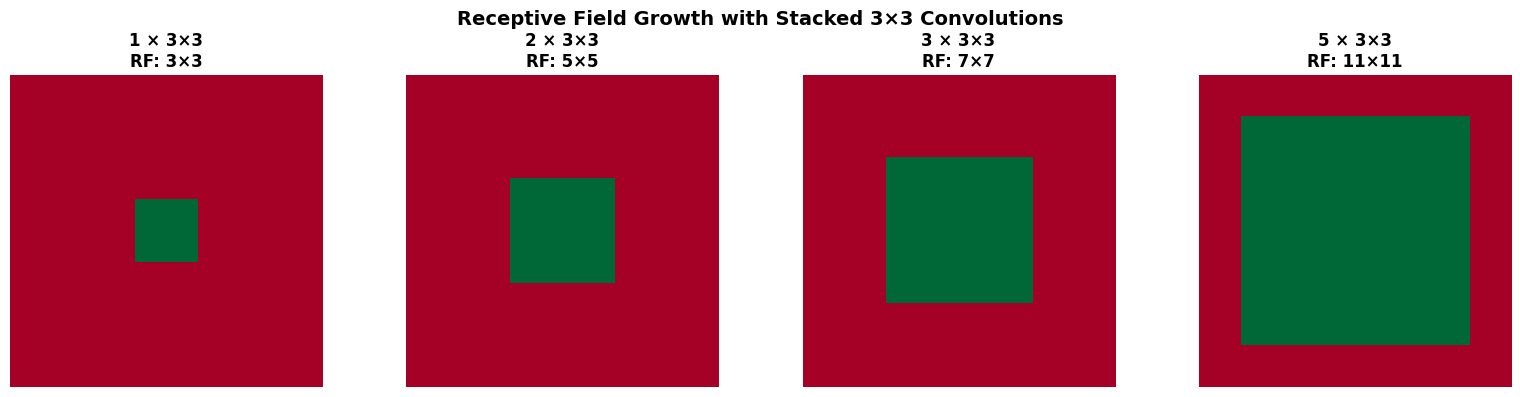

💡 AlexNet's 11×11 first layer = 5 stacked 3×3 layers
   But stacking gives 5× more non-linearity!


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Create visualization of receptive field growth
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

configs = [
    (3, '1 × 3×3\nRF: 3×3'),
    (5, '2 × 3×3\nRF: 5×5'),
    (7, '3 × 3×3\nRF: 7×7'),
    (11, '5 × 3×3\nRF: 11×11')
]

for ax, (size, title) in zip(axes, configs):
    grid = np.zeros((15, 15))
    center = 7
    half = size // 2
    grid[center-half:center+half+1, center-half:center+half+1] = 1
    
    ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    ax.grid(True, which='both', color='black', linewidth=0.5, alpha=0.3)

plt.suptitle('Receptive Field Growth with Stacked 3×3 Convolutions', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 AlexNet's 11×11 first layer = 5 stacked 3×3 layers")
print("   But stacking gives 5× more non-linearity!")

## 5. Data Preparation

### Define CIFAR-10 normalization

Use precomputed mean and std for CIFAR-10.

In [7]:
from torchvision import transforms

# CIFAR-10 dataset statistics
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2023, 0.1994, 0.2010)

print(f"CIFAR-10 normalization:")
print(f"  Mean: {CIFAR_MEAN}")
print(f"  Std:  {CIFAR_STD}")

CIFAR-10 normalization:
  Mean: (0.4914, 0.4822, 0.4465)
  Std:  (0.2023, 0.1994, 0.201)


### Create training transforms

Apply data augmentation to improve generalization.

In [8]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(
        brightness=CONFIG['brightness'],
        contrast=CONFIG['contrast'],
        saturation=CONFIG['saturation']
    ),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

print("Training augmentations:")
print("  ✓ Random horizontal flip")
print("  ✓ Random crop with padding")
print("  ✓ Color jitter")
print("  ✓ Normalization")

Training augmentations:
  ✓ Random horizontal flip
  ✓ Random crop with padding
  ✓ Color jitter
  ✓ Normalization


### Create test transforms

Only normalize test data (no augmentation).

In [9]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

print("Test transforms:")
print("  ✓ Normalization only (no augmentation)")

Test transforms:
  ✓ Normalization only (no augmentation)


### Load CIFAR-10 dataset

Download and prepare training and test sets.

In [10]:
from torchvision import datasets

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

print(f"Dataset loaded:")
print(f"  Training samples: {len(train_dataset):,}")
print(f"  Test samples:     {len(test_dataset):,}")
print(f"  Classes:          {CONFIG['num_classes']}")

Dataset loaded:
  Training samples: 50,000
  Test samples:     10,000
  Classes:          10


### Create data loaders

Set up efficient batch loading for training and validation.

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

val_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"Data loaders created:")
print(f"  Batch size:    {CONFIG['batch_size']}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")

Data loaders created:
  Batch size:    128
  Train batches: 391
  Val batches:   79


## 6. VGG Architecture Design

### VGG family overview

Understand the different VGG variants.

In [12]:
print("VGG Family (Simonyan & Zisserman, 2014):\n")
print("All variants share:")
print("  • All conv filters are 3×3 (stride 1, padding 1)")
print("  • All pooling is 2×2 MaxPool (stride 2)")
print("  • Channels double after each pool: 64→128→256→512→512")
print("  • Three FC layers at the end\n")

print("Variants (differ only in depth):\n")
variants = [
    ('VGG-11', 8, 3, 'Simplest'),
    ('VGG-13', 10, 3, 'Medium'),
    ('VGG-16', 13, 3, 'Most popular'),
    ('VGG-19', 16, 3, 'Deepest')
]

for name, conv_layers, fc_layers, note in variants:
    print(f"  {name}: {conv_layers} conv + {fc_layers} FC ({note})")

print("\n✅ Uniform design makes depth scaling systematic")

VGG Family (Simonyan & Zisserman, 2014):

All variants share:
  • All conv filters are 3×3 (stride 1, padding 1)
  • All pooling is 2×2 MaxPool (stride 2)
  • Channels double after each pool: 64→128→256→512→512
  • Three FC layers at the end

Variants (differ only in depth):

  VGG-11: 8 conv + 3 FC (Simplest)
  VGG-13: 10 conv + 3 FC (Medium)
  VGG-16: 13 conv + 3 FC (Most popular)
  VGG-19: 16 conv + 3 FC (Deepest)

✅ Uniform design makes depth scaling systematic


### VGG-11 configuration

Define the layer structure for VGG-11.

In [13]:
print("VGG-11 Configuration:\n")
print("Block 1: [64] + MaxPool")
print("  Input:  3×32×32")
print("  Output: 64×16×16\n")

print("Block 2: [128] + MaxPool")
print("  Input:  64×16×16")
print("  Output: 128×8×8\n")

print("Block 3: [256, 256] + MaxPool")
print("  Input:  128×8×8")
print("  Output: 256×4×4\n")

print("Block 4: [512, 512] + MaxPool")
print("  Input:  256×4×4")
print("  Output: 512×2×2\n")

print("Block 5: [512, 512] + MaxPool")
print("  Input:  512×2×2")
print("  Output: 512×1×1\n")

print("Classifier: FC(512→512→10)")
print("\nNotation: [64] = one 3×3 conv with 64 channels")
print("          [256, 256] = two 3×3 convs with 256 channels")

VGG-11 Configuration:

Block 1: [64] + MaxPool
  Input:  3×32×32
  Output: 64×16×16

Block 2: [128] + MaxPool
  Input:  64×16×16
  Output: 128×8×8

Block 3: [256, 256] + MaxPool
  Input:  128×8×8
  Output: 256×4×4

Block 4: [512, 512] + MaxPool
  Input:  256×4×4
  Output: 512×2×2

Block 5: [512, 512] + MaxPool
  Input:  512×2×2
  Output: 512×1×1

Classifier: FC(512→512→10)

Notation: [64] = one 3×3 conv with 64 channels
          [256, 256] = two 3×3 convs with 256 channels


### Implement VGG-11 with PyTorch Lightning

Create the model using Lightning for clean, modular code.

In [14]:
import torch
import torch.nn as nn
import lightning as L

class VGG11(L.LightningModule):
    def __init__(
        self,
        num_classes=CONFIG['num_classes'],
        learning_rate=CONFIG['learning_rate'],
        dropout=CONFIG['dropout']
    ):
        super().__init__()
        self.save_hyperparameters()
        
        # Feature extractor: 5 blocks of 3×3 convolutions
        self.features = nn.Sequential(
            # Block 1: 32×32 → 16×16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2: 16×16 → 8×8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3: 8×8 → 4×4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4: 4×4 → 2×2
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 5: 2×2 → 1×1
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # Classifier: 3 fully-connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )
        
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

### Inspect model architecture

Verify the model structure and parameter count.

In [15]:
model = VGG11()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"VGG-11 Model Summary:")
print(f"  Total parameters:     {total_params:>10,}")
print(f"  Trainable parameters: {trainable_params:>10,}")
print(f"\nModel structure:")
print(model)

VGG-11 Model Summary:
  Total parameters:      9,756,426
  Trainable parameters:  9,756,426

Model structure:
VGG11(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps

### Test forward pass

Verify the model produces correct output shapes.

In [16]:
# Test with dummy input
dummy_input = torch.randn(1, 3, 32, 32)
output = model(dummy_input)

print(f"Forward pass test:")
print(f"  Input shape:  {tuple(dummy_input.shape)}")
print(f"  Output shape: {tuple(output.shape)}")
print(f"  Expected:     (1, {CONFIG['num_classes']})")
print(f"\n✅ Forward pass successful!")

Forward pass test:
  Input shape:  (1, 3, 32, 32)
  Output shape: (1, 10)
  Expected:     (1, 10)

✅ Forward pass successful!


## 7. Compare to AlexNet

### Architectural comparison

Highlight the improvements VGG brings over AlexNet.

In [17]:
print("AlexNet vs VGG-11 Architecture:\n")
print(f"{'Aspect':<25} {'AlexNet':<25} {'VGG-11':<25}")
print("-" * 75)
print(f"{'Conv layers':<25} {'5':<25} {'8 ✓':<25}")
print(f"{'Filter sizes':<25} {'11×11, 5×5, 3×3':<25} {'All 3×3 ✓':<25}")
print(f"{'Design principle':<25} {'Heterogeneous':<25} {'Uniform ✓':<25}")
print(f"{'Channel progression':<25} {'64→192→384→256':<25} {'64→128→256→512 ✓':<25}")
print(f"{'Depth scalability':<25} {'Unclear':<25} {'Systematic ✓':<25}")
print(f"{'Params (CIFAR-10)':<25} {'~14.8M':<25} {f'~{total_params/1e6:.1f}M ✓':<25}")

print("\nVGG Advantages:")
print("  ✓ Uniform design (easier to understand and implement)")
print("  ✓ Systematic depth scaling (add more 3×3 blocks)")
print("  ✓ More non-linearity per receptive field")
print("  ✓ Fewer parameters in conv layers")
print("  ✓ Clearer design principles")

AlexNet vs VGG-11 Architecture:

Aspect                    AlexNet                   VGG-11                   
---------------------------------------------------------------------------
Conv layers               5                         8 ✓                      
Filter sizes              11×11, 5×5, 3×3           All 3×3 ✓                
Design principle          Heterogeneous             Uniform ✓                
Channel progression       64→192→384→256            64→128→256→512 ✓         
Depth scalability         Unclear                   Systematic ✓             
Params (CIFAR-10)         ~14.8M                    ~9.8M ✓                  

VGG Advantages:
  ✓ Uniform design (easier to understand and implement)
  ✓ Systematic depth scaling (add more 3×3 blocks)
  ✓ More non-linearity per receptive field
  ✓ Fewer parameters in conv layers
  ✓ Clearer design principles


## 8. Training

### Create trainer with early stopping

Set up Lightning trainer with logging and early stopping.

In [18]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

# Initialize model
model = VGG11()

# Create logger
logger = CSVLogger('logs', name='vgg11')

# Create early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG['early_stop_patience'],
    mode='min',
    verbose=False
)

# Create trainer
trainer = L.Trainer(
    max_epochs=CONFIG['max_epochs'],
    accelerator='auto',
    devices=1,
    logger=logger,
    callbacks=[early_stop],
    enable_progress_bar=True
)

print(f"Training configuration:")
print(f"  Max epochs:          {CONFIG['max_epochs']}")
print(f"  Early stop patience: {CONFIG['early_stop_patience']}")
print(f"  Learning rate:       {CONFIG['learning_rate']}")
print(f"  Batch size:          {CONFIG['batch_size']}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training configuration:
  Max epochs:          50
  Early stop patience: 5
  Learning rate:       0.001
  Batch size:          128


### Train the model

Run training with automatic device management and metric logging.

In [19]:
print("Starting training...\n")
trainer.fit(model, train_loader, val_loader)
print("\n✅ Training complete!")

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precis

Starting training...



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type             | Params | Mode 
--------------------------------------------------------
0 | features   | Sequential       | 9.2 M  | train
1 | classifier | Sequential       | 530 K  | train
2 | criterion  | CrossEntropyLoss | 0      | train
--------------------------------------------------------
9.8 M     Trainable params
0         Non-trainable params
9.8 M     Total params
39.026    Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✅ Training complete!


## 9. Results Analysis

### Load training metrics

Read the logged metrics from CSV.

In [20]:
import pandas as pd

# Read metrics from CSV logger
metrics = pd.read_csv(f'{logger.log_dir}/metrics.csv')

# Aggregate by epoch
train_metrics = metrics[['epoch', 'train_loss', 'train_acc']].dropna()
val_metrics = metrics[['epoch', 'val_loss', 'val_acc']].dropna()
train_metrics = train_metrics.groupby('epoch').mean().reset_index()
val_metrics = val_metrics.groupby('epoch').mean().reset_index()

print(f"Training statistics:")
print(f"  Epochs trained: {len(train_metrics)}")
print(f"  Final train loss: {train_metrics['train_loss'].iloc[-1]:.4f}")
print(f"  Final val loss:   {val_metrics['val_loss'].iloc[-1]:.4f}")

Training statistics:
  Epochs trained: 32
  Final train loss: 0.1724
  Final val loss:   0.3847


### Plot training curves

Visualize how the model learned over time.

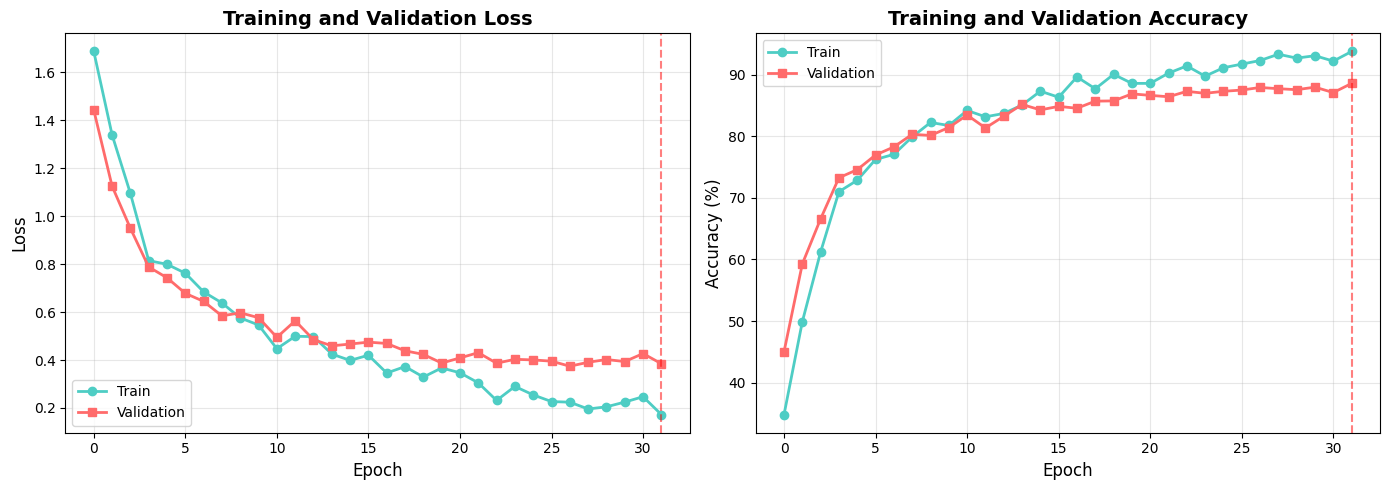

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(train_metrics['epoch'], train_metrics['train_loss'],
         label='Train', marker='o', linewidth=2, color='#4ECDC4')
ax1.plot(val_metrics['epoch'], val_metrics['val_loss'],
         label='Validation', marker='s', linewidth=2, color='#FF6B6B')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mark early stopping point if triggered
if trainer.early_stopping_callback and trainer.early_stopping_callback.stopped_epoch > 0:
    stop_epoch = trainer.early_stopping_callback.stopped_epoch
    ax1.axvline(x=stop_epoch, color='red', linestyle='--', alpha=0.5, label='Early Stop')

# Accuracy curves
ax2.plot(train_metrics['epoch'], train_metrics['train_acc'] * 100,
         label='Train', marker='o', linewidth=2, color='#4ECDC4')
ax2.plot(val_metrics['epoch'], val_metrics['val_acc'] * 100,
         label='Validation', marker='s', linewidth=2, color='#FF6B6B')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mark early stopping point if triggered
if trainer.early_stopping_callback and trainer.early_stopping_callback.stopped_epoch > 0:
    ax2.axvline(x=stop_epoch, color='red', linestyle='--', alpha=0.5, label='Early Stop')

plt.tight_layout()
plt.show()

### Print final results

Summarize the training outcome.

In [22]:
epochs_trained = len(train_metrics)

print(f"Training Statistics:")
print(f"  Epochs trained: {epochs_trained} / {CONFIG['max_epochs']}")

if trainer.early_stopping_callback and trainer.early_stopping_callback.stopped_epoch > 0:
    print(f"  Early stopping triggered at epoch {trainer.early_stopping_callback.stopped_epoch}")

print(f"\nFinal Results:")
print(f"  Train Accuracy: {train_metrics['train_acc'].iloc[-1]*100:.2f}%")
print(f"  Val Accuracy:   {val_metrics['val_acc'].iloc[-1]*100:.2f}%")
print(f"  Overfitting Gap: {(train_metrics['train_acc'].iloc[-1] - val_metrics['val_acc'].iloc[-1])*100:.2f}%")

Training Statistics:
  Epochs trained: 32 / 50
  Early stopping triggered at epoch 31

Final Results:
  Train Accuracy: 93.75%
  Val Accuracy:   88.57%
  Overfitting Gap: 5.18%


## 10. VGG's Limitations

VGG proved depth and uniformity work, but revealed new problems that motivated Inception.

### Limitation 1: FC layers dominate parameters

Calculate parameter distribution between conv and FC layers.

In [23]:
# Count parameters by layer type
conv_params = sum(p.numel() for name, p in model.named_parameters() 
                  if 'features' in name)
fc_params = sum(p.numel() for name, p in model.named_parameters() 
                if 'classifier' in name)
total = conv_params + fc_params

print(f"VGG-11 Parameter Distribution:\n")
print(f"  Convolutional layers: {conv_params:>10,} ({100*conv_params/total:>5.1f}%)")
print(f"  Fully-connected:      {fc_params:>10,} ({100*fc_params/total:>5.1f}%)")
print(f"  Total:                {total:>10,}")

print(f"\n⚠️  Original VGG-16 on ImageNet: 138M parameters!")
print(f"  • 90% are in FC layers")
print(f"  • First FC layer: 7×7×512 × 4096 = 102M params")
print(f"  • Makes model huge and slow")

print(f"\n✅ Solution (Inception & beyond): Global Average Pooling")
print(f"  • Replace FC layers with average pooling")
print(f"  • Drastically reduces parameters")
print(f"  • Enables variable input sizes")

VGG-11 Parameter Distribution:

  Convolutional layers:  9,225,984 ( 94.6%)
  Fully-connected:         530,442 (  5.4%)
  Total:                 9,756,426

⚠️  Original VGG-16 on ImageNet: 138M parameters!
  • 90% are in FC layers
  • First FC layer: 7×7×512 × 4096 = 102M params
  • Makes model huge and slow

✅ Solution (Inception & beyond): Global Average Pooling
  • Replace FC layers with average pooling
  • Drastically reduces parameters
  • Enables variable input sizes


### Visualize parameter distribution

Show the imbalance between conv and FC layers.

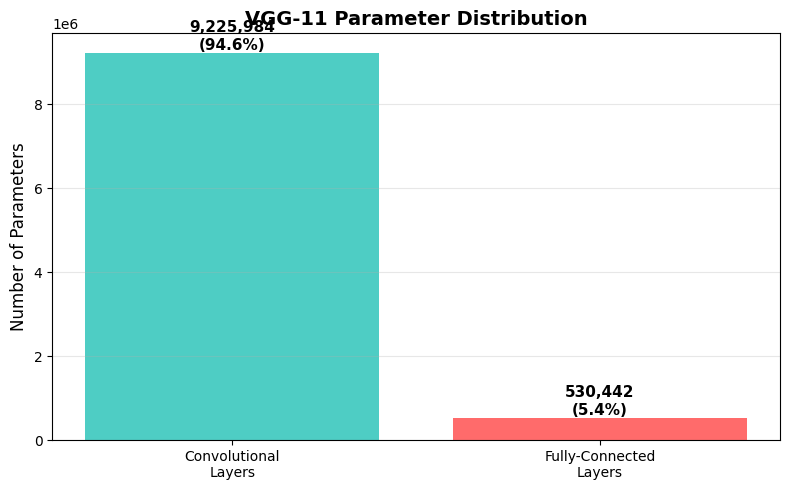

💡 FC layers are a bottleneck despite efficient 3×3 convs!


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ['Convolutional\nLayers', 'Fully-Connected\nLayers'],
    [conv_params, fc_params],
    color=['#4ECDC4', '#FF6B6B']
)

ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('VGG-11 Parameter Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({100*height/total:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 FC layers are a bottleneck despite efficient 3×3 convs!")

### Limitation 2: Computational inefficiency

VGG's uniform depth means uniform computation everywhere—but not all features need the same capacity.

In [25]:
print("VGG's Computational Uniformity Problem:\n")
print("Real images have features at multiple scales:")
print("  • Fine details (eyes, text) → need small receptive fields")
print("  • Large objects (cars, sky) → need large receptive fields\n")

print("VGG's approach:")
print("  ❌ All features pass through same # of 3×3 layers")
print("  ❌ No adaptation to different scales")
print("  ❌ Computationally wasteful\n")

print("Inception's solution:")
print("  ✓ Run 1×1, 3×3, 5×5 convs in parallel")
print("  ✓ Let network learn which scale matters where")
print("  ✓ More efficient than brute-force depth")

VGG's Computational Uniformity Problem:

Real images have features at multiple scales:
  • Fine details (eyes, text) → need small receptive fields
  • Large objects (cars, sky) → need large receptive fields

VGG's approach:
  ❌ All features pass through same # of 3×3 layers
  ❌ No adaptation to different scales
  ❌ Computationally wasteful

Inception's solution:
  ✓ Run 1×1, 3×3, 5×5 convs in parallel
  ✓ Let network learn which scale matters where
  ✓ More efficient than brute-force depth


### Limitation 3: Single-scale features

Every VGG layer sees the world at one scale (3×3 windows).

In [26]:
print("Single-Scale vs Multi-Scale Processing:\n")
print("VGG (Single-Scale):")
print("  Layer 1: 3×3 conv")
print("  Layer 2: 3×3 conv")
print("  Layer 3: 3×3 conv")
print("  → All layers see same-size neighborhoods\n")

print("Inception (Multi-Scale):")
print("  Each layer runs:")
print("    • 1×1 conv (point features)")
print("    • 3×3 conv (local features)")
print("    • 5×5 conv (regional features)")
print("    • Pooling (spatial aggregation)")
print("  → Network chooses best scale per location\n")

print("💡 VGG is like using one tool for every job.")
print("   Inception is like having multiple tools and choosing the best one.")

Single-Scale vs Multi-Scale Processing:

VGG (Single-Scale):
  Layer 1: 3×3 conv
  Layer 2: 3×3 conv
  Layer 3: 3×3 conv
  → All layers see same-size neighborhoods

Inception (Multi-Scale):
  Each layer runs:
    • 1×1 conv (point features)
    • 3×3 conv (local features)
    • 5×5 conv (regional features)
    • Pooling (spatial aggregation)
  → Network chooses best scale per location

💡 VGG is like using one tool for every job.
   Inception is like having multiple tools and choosing the best one.


### Visualize single vs multi-scale

Compare VGG's uniform approach to Inception's parallel paths.

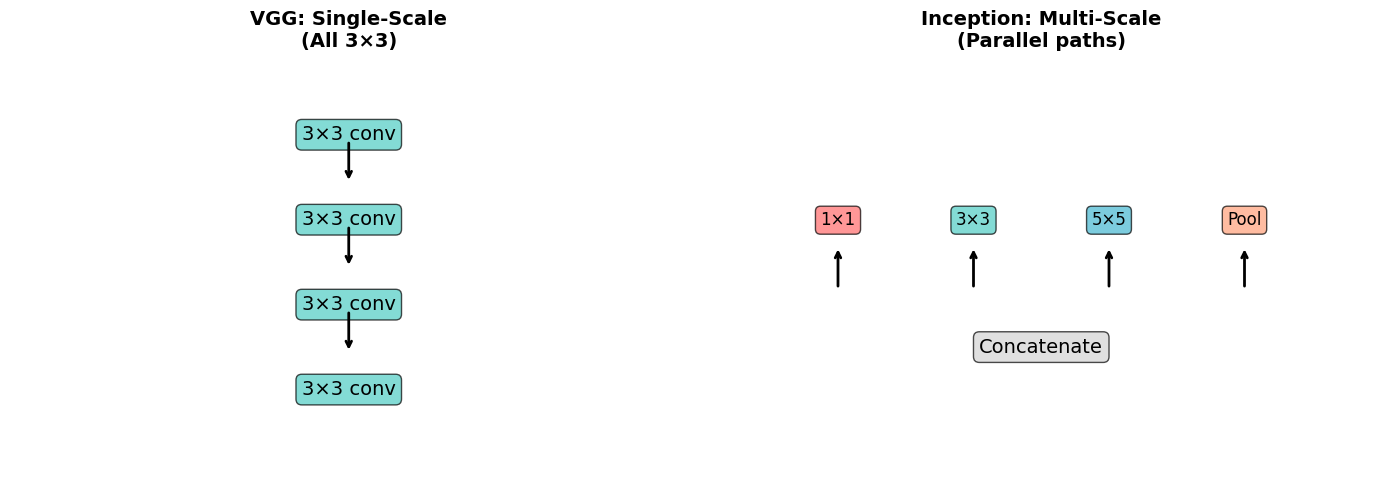

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VGG: uniform 3×3
axes[0].text(0.5, 0.8, '3×3 conv', ha='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.7))
axes[0].text(0.5, 0.6, '3×3 conv', ha='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.7))
axes[0].text(0.5, 0.4, '3×3 conv', ha='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.7))
axes[0].text(0.5, 0.2, '3×3 conv', ha='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.7))

for y in [0.75, 0.55, 0.35]:
    axes[0].annotate('', xy=(0.5, y-0.05), xytext=(0.5, y+0.05),
                    arrowprops=dict(arrowstyle='->', lw=2))

axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_title('VGG: Single-Scale\n(All 3×3)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Inception: multi-scale
y_pos = 0.6
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
labels = ['1×1', '3×3', '5×5', 'Pool']
x_positions = [0.2, 0.4, 0.6, 0.8]

for x, label, color in zip(x_positions, labels, colors):
    axes[1].text(x, y_pos, label, ha='center', fontsize=12,
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
    axes[1].annotate('', xy=(x, y_pos-0.05), xytext=(x, y_pos-0.15),
                    arrowprops=dict(arrowstyle='->', lw=2))

axes[1].text(0.5, 0.3, 'Concatenate', ha='center', fontsize=14,
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Inception: Multi-Scale\n(Parallel paths)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Limitation 4: Memory consumption

Deep uniform networks require storing activations for every layer during backprop.

In [28]:
batch_size = CONFIG['batch_size']

print(f"Memory Cost During Training (batch size {batch_size}):\n")
print("Activations stored for backprop:\n")

blocks = [
    ('Block 1', 32, 64),
    ('Block 2', 16, 128),
    ('Block 3', 8, 256),
    ('Block 4', 4, 512),
    ('Block 5', 2, 512),
]

total_values = 0
for name, spatial_size, channels in blocks:
    values = batch_size * spatial_size * spatial_size * channels
    total_values += values
    print(f"  {name} ({spatial_size}×{spatial_size}×{channels}): "
          f"{batch_size} × {spatial_size} × {spatial_size} × {channels:3d} = {values/1e6:.1f}M values")

memory_mb = total_values * 4 / (1024 * 1024)  # float32 = 4 bytes

print(f"\n  Total: ~{total_values/1e6:.0f}M float32 values = ~{memory_mb:.0f} MB")
print(f"  (And this is for tiny 32×32 images!)\n")

print(f"Original VGG-16 on 224×224 ImageNet:")
print(f"  • ~96 MB per image")
print(f"  • Batch of 32 = 3 GB memory!\n")

print(f"⚠️  This limits batch size and training speed.")

Memory Cost During Training (batch size 128):

Activations stored for backprop:

  Block 1 (32×32×64): 128 × 32 × 32 ×  64 = 8.4M values
  Block 2 (16×16×128): 128 × 16 × 16 × 128 = 4.2M values
  Block 3 (8×8×256): 128 × 8 × 8 × 256 = 2.1M values
  Block 4 (4×4×512): 128 × 4 × 4 × 512 = 1.0M values
  Block 5 (2×2×512): 128 × 2 × 2 × 512 = 0.3M values

  Total: ~16M float32 values = ~61 MB
  (And this is for tiny 32×32 images!)

Original VGG-16 on 224×224 ImageNet:
  • ~96 MB per image
  • Batch of 32 = 3 GB memory!

⚠️  This limits batch size and training speed.


## 11. Summary: VGG's Legacy

### What VGG got right

VGG's lasting contributions to deep learning.

In [29]:
print("VGG's Innovations:\n")
print("✅ Uniform 3×3 filters")
print("   • Simple, scalable, parameter-efficient")
print("   • Became the standard conv filter size\n")

print("✅ Systematic depth")
print("   • Clear path to go deeper (VGG-11/13/16/19)")
print("   • Proved depth matters\n")

print("✅ Stacked small filters")
print("   • Same receptive field as large filters")
print("   • More non-linearity")
print("   • Fewer parameters\n")

print("✅ Elegant design")
print("   • One simple rule instead of many hyperparameters")
print("   • Easy to understand and implement\n")

print("Result: Uniform, deep architectures outperform heterogeneous designs.")

VGG's Innovations:

✅ Uniform 3×3 filters
   • Simple, scalable, parameter-efficient
   • Became the standard conv filter size

✅ Systematic depth
   • Clear path to go deeper (VGG-11/13/16/19)
   • Proved depth matters

✅ Stacked small filters
   • Same receptive field as large filters
   • More non-linearity
   • Fewer parameters

✅ Elegant design
   • One simple rule instead of many hyperparameters
   • Easy to understand and implement

Result: Uniform, deep architectures outperform heterogeneous designs.


### What Inception improved

How Inception addressed VGG's limitations.

In [30]:
print("Inception's Solutions to VGG's Problems:\n")

problems = [
    ('FC layers dominate', 'Global Average Pooling (no FC layers!)'),
    ('Single-scale features', 'Multi-scale parallel convs (1×1, 3×3, 5×5)'),
    ('Uniform computation', '1×1 bottleneck layers reduce computation'),
    ('Massive parameters', 'Efficient design: 5M params vs VGG\'s 138M'),
]

for problem, solution in problems:
    print(f"Problem:  {problem}")
    print(f"Solution: {solution}\n")

Inception's Solutions to VGG's Problems:

Problem:  FC layers dominate
Solution: Global Average Pooling (no FC layers!)

Problem:  Single-scale features
Solution: Multi-scale parallel convs (1×1, 3×3, 5×5)

Problem:  Uniform computation
Solution: 1×1 bottleneck layers reduce computation

Problem:  Massive parameters
Solution: Efficient design: 5M params vs VGG's 138M



### Architecture evolution timeline

See how ideas built on each other.

In [31]:
print("CNN Architecture Evolution:\n")
print("LeNet (1998):")
print("  ❌ Too shallow, too few filters\n")

print("AlexNet (2012):")
print("  ✅ Depth + capacity + ReLU + Dropout")
print("  ❌ Large filters, heterogeneous design\n")

print("VGG (2014):")
print("  ✅ Uniform 3×3 filters, systematic depth")
print("  ❌ Parameter explosion, single-scale, FC-heavy\n")

print("Inception (2014):")
print("  ✅ Multi-scale, efficient, no FC layers")
print("  ✅ 5M params, better accuracy than VGG-19")
print("  ❌ Complex architecture, hard to modify\n")

print("ResNet (2015):")
print("  ✅ Skip connections enable extreme depth (1000+ layers)")
print("  ✅ Solves vanishing gradients")

CNN Architecture Evolution:

LeNet (1998):
  ❌ Too shallow, too few filters

AlexNet (2012):
  ✅ Depth + capacity + ReLU + Dropout
  ❌ Large filters, heterogeneous design

VGG (2014):
  ✅ Uniform 3×3 filters, systematic depth
  ❌ Parameter explosion, single-scale, FC-heavy

Inception (2014):
  ✅ Multi-scale, efficient, no FC layers
  ✅ 5M params, better accuracy than VGG-19
  ❌ Complex architecture, hard to modify

ResNet (2015):
  ✅ Skip connections enable extreme depth (1000+ layers)
  ✅ Solves vanishing gradients


## 12. Key Takeaways

**VGG's core contributions:**

1. **Uniformity scales** - One design rule (3×3 everywhere) beats ad-hoc choices
2. **Stacked small filters win** - Same receptive field, more non-linearity, fewer parameters
3. **Depth matters** - Systematic depth scaling improves performance
4. **Simplicity is powerful** - Easy to understand, implement, and modify

**VGG's limitations that led to Inception:**

1. **FC layers bottleneck** - Most parameters, limited flexibility → Global Average Pooling
2. **Single-scale wasteful** - Not all features need same treatment → Multi-scale parallel convs
3. **Computational inefficiency** - Uniform depth everywhere → 1×1 bottleneck layers
4. **Parameter explosion** - Deep = huge → More efficient architectures

**Next steps:**

In the **Inception notebook**, we'll see:
- How parallel multi-scale convolutions capture features at different scales
- How 1×1 bottleneck layers dramatically reduce computation
- How Global Average Pooling eliminates FC layers entirely
- How Network-in-Network concepts enable auxiliary classifiers